# 🛰️ GeoAI vs LiDAR Canopy Height — Method Validation Study

**Author:** Dr. Sonali Sharma  
**Data:** LiDAR-derived CHM (Notebook 02) + Helsinki City WMS orthophoto (2021, 5 cm)

---

## Project Overview

LiDAR surveys produce highly accurate canopy height data but are expensive, infrequent, and require specialist processing. Deep learning models trained on satellite and aerial imagery offer a cheaper, more scalable alternative — but how well do they actually perform?

This notebook presents a **pixel-level validation** of package `geoai`'s `CanopyHeightEstimation` model (SSL-pretrained on aerial imagery) against our LiDAR-derived CHM from Notebook 02, treating the LiDAR product as ground truth.

### What this notebook covers

| Stage | Description |
|-------|-------------|
| **1. Data preparation** | Load LiDAR CHM; fetch matched orthophoto from Helsinki WMS; fix georeference |
| **2. GeoAI prediction** | Run `CanopyHeightEstimation` (SSL-huge model) on the orthophoto |
| **3. Vegetation masking** | Restrict comparison to vegetated pixels using LiDAR CHM as reference mask |
| **4. Visual comparison** | Side-by-side CHM maps on matched colour scale |
| **5. Statistical validation** | Height distribution, scatter plot, R², RMSE, and mean bias |
| **6. Residual map** | Spatially explicit error map — where does GeoAI over- or underestimate? |
| **7. Interpretation** | Structured summary of when GeoAI is reliable vs. when LiDAR is still needed |

### Why this matters for practice
Understanding the **spatial pattern of errors** — not just the average accuracy — tells you which planning decisions can safely rely on GeoAI outputs and which require LiDAR-quality data. This is the question practitioners actually need answered.

---

## Data Sources

| Dataset | Source | Licence |
|---------|--------|---------|
| **LiDAR CHM** | Derived in Notebook 02 from Helsinki open LiDAR | Helsinki open data |
| **Orthophoto** | Helsinki City WMS — `avoindata:Ortoilmakuva_2021_5cm` | Helsinki open data |
| **GeoAI model** | `geoai` package — `compressed_SSLhuge_aerial` | Meta / open weights |

---

## 0. Imports and Configuration

In [2]:
# ── Standard library ──────────────────────────────────────────────────────────
from pathlib import Path

# ── Geospatial ────────────────────────────────────────────────────────────────
import requests
import rasterio
from rasterio.transform import from_bounds

# ── GeoAI — deep learning canopy height model ─────────────────────────────────
import geoai
from geoai.canopy import CanopyHeightEstimation

# ── Numerical ─────────────────────────────────────────────────────────────────
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.ticker import ScalarFormatter

print("✓ All imports successful")

✓ All imports successful


In [4]:
# ── Project configuration — update DATA_DIR to your local path ────────────────
DATA_DIR = Path("E:/Py/3D/LAS/Neigh")   # ← change this to your data folder

# Inputs
CHM_LIDAR_PATH = DATA_DIR / "chm_veg_05m_clean.tif"   # from Notebook 02

# Intermediate outputs
ORTHO_RAW_PATH   = DATA_DIR / "orthophoto_2021.tif"         # downloaded from WMS
ORTHO_FIXED_PATH = DATA_DIR / "orthophoto_2021_geo.tif"     # georeferenced to CHM grid

# Final outputs
CHM_GEOAI_PATH        = DATA_DIR / "chm_geoai_predict.tif"
CHM_GEOAI_MASKED_PATH = DATA_DIR / "chm_geoai_predict_vegmasked.tif"

# WMS parameters — Helsinki City open orthophoto service
WMS_URL   = "https://kartta.hel.fi/ws/geoserver/avoindata/wms"
WMS_LAYER = "avoindata:Ortoilmakuva_2021_5cm"

# GeoAI model
GEOAI_MODEL = "compressed_SSLhuge_aerial"   # SSL-pretrained on aerial imagery
BATCH_SIZE  = 4

print("✓ Configuration set")

✓ Configuration set


---
## Step 1 — Load LiDAR CHM and Fetch Matched Orthophoto

The LiDAR CHM was produced in Notebook 02. We read its spatial metadata (extent, CRS, resolution) and use it to request a pixel-for-pixel matched orthophoto from the Helsinki City WMS service — ensuring both datasets share the same grid before we pass the orthophoto to the GeoAI model.

In [6]:
# ── Load LiDAR CHM — this is our ground truth reference ──────────────────────
with rasterio.open(str(CHM_LIDAR_PATH)) as src:
    chm_lidar = src.read(1)
    chm_transform = src.transform
    chm_bounds    = src.bounds
    chm_crs       = src.crs
    chm_res       = src.res
    chm_width     = src.width
    chm_height    = src.height
    chm_profile   = src.profile.copy()

print("LiDAR CHM (ground truth):")
print(f"  Shape      : {chm_height} rows × {chm_width} cols")
print(f"  Resolution : {chm_res[0]} m × {chm_res[1]} m")
print(f"  CRS        : {chm_crs}")
print(f"  Bounds     : {chm_bounds}")
print(f"  Height range : {np.nanmin(chm_lidar):.1f} m → {np.nanmax(chm_lidar):.1f} m")

LiDAR CHM (ground truth):
  Shape      : 1000 rows × 1000 cols
  Resolution : 0.5 m × 0.5 m
  CRS        : EPSG:3879
  Bounds     : BoundingBox(left=25501500.0, bottom=6674999.999, right=25502000.0, top=6675499.999)
  Height range : 0.5 m → 40.1 m


In [4]:
# ── Fetch orthophoto from Helsinki WMS at exactly the CHM extent and size ─────
# Requesting WIDTH=chm_width and HEIGHT=chm_height with the CHM bounding box
# guarantees pixel-for-pixel spatial correspondence between the two datasets.

params = {
    "SERVICE": "WMS",
    "VERSION": "1.1.1",
    "REQUEST": "GetMap",
    "LAYERS": WMS_LAYER,
    "STYLES": "",
    "SRS": "EPSG:3879",
    "BBOX": f"{chm_bounds.left},{chm_bounds.bottom},{chm_bounds.right},{chm_bounds.top}",
    "WIDTH": chm_width,
    "HEIGHT": chm_height,
    "FORMAT": "image/tiff"
}

response = requests.get(WMS_URL, params=params, timeout=60)
response.raise_for_status()

with open(str(ORTHO_RAW_PATH), "wb") as f:
    f.write(response.content)

print(f"✓ Orthophoto downloaded → {ORTHO_RAW_PATH}")

✓ Orthophoto downloaded → E:\Py\3D\LAS\Neigh\orthophoto_2021.tif


In [5]:
# ── Fix the orthophoto georeference ──────────────────────────────────────────
# WMS responses often return a GeoTIFF without a valid spatial reference (the CRS and transform are missing or generic). 
# We fix this by computing the correct transform from the CHM bounding box and writing it into the raster profile before saving. 
# This ensures the orthophoto is pixel-aligned with the CHM when both are opened in any GIS tool.

with rasterio.open(str(ORTHO_RAW_PATH)) as src:
    ortho_data    = src.read()
    ortho_profile = src.profile.copy()

# Compute correct affine transform from CHM extent
fixed_transform = from_bounds(
    chm_bounds.left, chm_bounds.bottom,
    chm_bounds.right, chm_bounds.top,
    chm_width, chm_height
)

ortho_profile.update({
    "crs"       : chm_crs,
    "transform" : fixed_transform,
    "width"     : chm_width,
    "height"    : chm_height
})

with rasterio.open(str(ORTHO_FIXED_PATH), "w", **ortho_profile) as dst:
    dst.write(ortho_data)

print(f"✓ Georeferenced orthophoto saved → {ORTHO_FIXED_PATH}")

# Verify alignment
with rasterio.open(str(ORTHO_FIXED_PATH)) as src:
    print(f"\nAlignment check:")
    print(f"  CRS match    : {src.crs == chm_crs}")
    print(f"  Shape match  : {(src.height, src.width) == (chm_height, chm_width)}")
    print(f"  Bounds match : {src.bounds == chm_bounds}")

✓ Georeferenced orthophoto saved → E:\Py\3D\LAS\Neigh\orthophoto_2021_geo.tif

Alignment check:
  CRS match    : True
  Shape match  : True
  Bounds match : True


C:\Users\Asus\anaconda3\envs\GEOAIcourse\Lib\site-packages\rasterio\__init__.py:356: NotGeoreferencedWarning: Dataset has no geotransform, gcps, or rpcs. The identity matrix will be returned.
  dataset = DatasetReader(path, driver=driver, sharing=sharing, **kwargs)


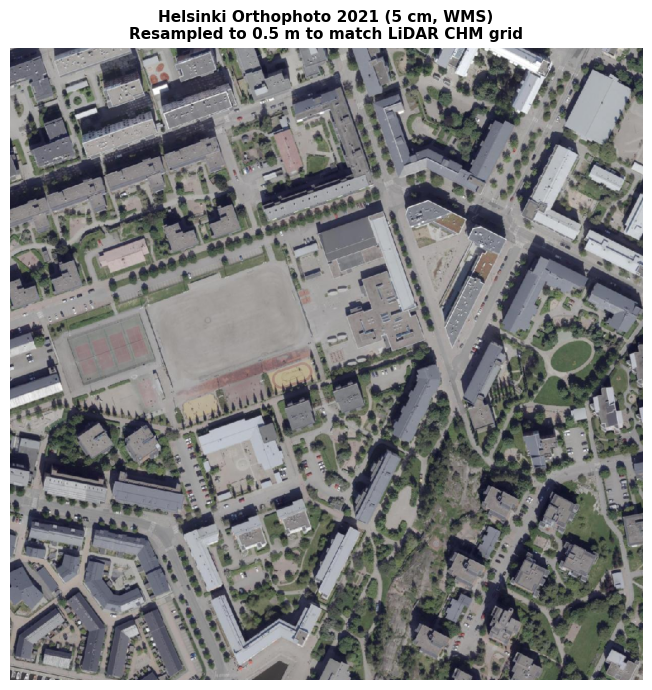

In [6]:
# ── Visualise the fetched orthophoto ─────────────────────────────────────────
with rasterio.open(str(ORTHO_FIXED_PATH)) as src:
    ortho_rgb = src.read()[:3]   # first 3 bands = RGB

# Move to (H, W, 3) for matplotlib
ortho_display = np.moveaxis(ortho_rgb, 0, 2)

fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(ortho_display)
ax.set_title("Helsinki Orthophoto 2021 (5 cm, WMS)\nResampled to 0.5 m to match LiDAR CHM grid",
             fontsize=11, fontweight="bold")
ax.axis("off")
plt.tight_layout()
plt.show()

---
## Step 2 — Run GeoAI Canopy Height Estimation

We run the `CanopyHeightEstimation` model from the `geoai` package. We follow the tutorial (https://colab.research.google.com/github/opengeos/geoai/blob/main/docs/examples/canopy_height.ipynb).

The model (`compressed_SSLhuge_aerial`) was pre-trained using **self-supervised learning (SSL)** on large-scale aerial imagery datasets — it predicts canopy height from RGB input alone, with no LiDAR in the loop.

This is exactly the scenario where such a model is useful in practice: you have aerial imagery but no LiDAR, and you need a height estimate.

In [ ]:
# ── Run GeoAI canopy height prediction ───────────────────────────────────────

print(f"Running GeoAI model: {GEOAI_MODEL}")
print(f"Input  : {ORTHO_FIXED_PATH.name}")
print(f"Output : {CHM_GEOAI_PATH.name}")

estimator = CanopyHeightEstimation(model_name=GEOAI_MODEL)

estimator.predict(
    str(ORTHO_FIXED_PATH),
    output_path = str(CHM_GEOAI_PATH),
    batch_size  = BATCH_SIZE
)

print(f"\n✓ GeoAI prediction complete → {CHM_GEOAI_PATH}")

Running GeoAI model: compressed_SSLhuge_aerial
Input  : orthophoto_2021_geo.tif
Output : chm_geoai_predict.tif


In [7]:
# ── Load GeoAI prediction and inspect ────────────────────────────────────────
with rasterio.open(str(CHM_GEOAI_PATH)) as src:
    chm_geoai   = src.read(1)
    geoai_transform = src.transform
    geoai_crs   = src.crs

print("GeoAI CHM:")
print(f"  Shape      : {chm_geoai.shape}")
print(f"  CRS        : {geoai_crs}")
print(f"  Value range: {chm_geoai.min():.2f} → {chm_geoai.max():.2f} m")
print(f"\nLiDAR CHM (reference):")
print(f"  Value range: {np.nanmin(chm_lidar):.2f} → {np.nanmax(chm_lidar):.2f} m")

GeoAI CHM:
  Shape      : (1000, 1000)
  CRS        : EPSG:3879
  Value range: 0.00 → 16.61 m

LiDAR CHM (reference):
  Value range: 0.50 → 40.06 m


---
## Step 3 — Apply Vegetation Mask

We restrict the comparison to **vegetated pixels only**, using the LiDAR CHM as a reference mask (any pixel with LiDAR height > 0.01 m is considered vegetation).

This is important for two reasons:
1. The GeoAI model predicts height everywhere — including roads, buildings, and bare ground. Comparing on non-vegetation pixels would penalise GeoAI for predicting small positive values on surfaces where LiDAR correctly returns zero.
2. We are specifically interested in whether GeoAI can replace LiDAR for vegetation mapping — a like-for-like comparison on vegetation pixels is the scientifically correct question.

In [8]:
# ── Build vegetation mask from LiDAR CHM ─────────────────────────────────────
# Any pixel where LiDAR detected canopy above 1 cm is considered vegetation.
veg_mask = chm_lidar > 0.01

print(f"Vegetation mask:")
print(f"  Vegetated pixels : {veg_mask.sum():,} ({veg_mask.mean()*100:.1f}% of raster)")
print(f"  Non-vegetated    : {(~veg_mask).sum():,}")

# Apply mask to both CHMs — non-vegetated pixels become NaN
lidar_masked = chm_lidar.astype("float32").copy()
lidar_masked[~veg_mask] = np.nan

geoai_masked = chm_geoai.astype("float32").copy()
geoai_masked[~veg_mask] = np.nan

print(f"\nMasked value ranges:")
print(f"  LiDAR : {np.nanmin(lidar_masked):.2f} m → {np.nanmax(lidar_masked):.2f} m")
print(f"  GeoAI : {np.nanmin(geoai_masked):.2f} m → {np.nanmax(geoai_masked):.2f} m")

# Save masked GeoAI CHM for use in other analyses
out_profile = chm_profile.copy()
out_profile.update(dtype="float32", nodata=np.nan)

with rasterio.open(str(CHM_GEOAI_MASKED_PATH), "w", **out_profile) as dst:
    dst.write(geoai_masked, 1)

print(f"\n✓ Masked GeoAI CHM saved → {CHM_GEOAI_MASKED_PATH}")

Vegetation mask:
  Vegetated pixels : 238,797 (23.9% of raster)
  Non-vegetated    : 761,203

Masked value ranges:
  LiDAR : 0.50 m → 40.06 m
  GeoAI : 0.00 m → 16.61 m

✓ Masked GeoAI CHM saved → E:\Py\3D\LAS\Neigh\chm_geoai_predict_vegmasked.tif


---
## Step 4 — Visual Comparison

Side-by-side maps on a matched colour scale (0 m to the 99th percentile of LiDAR heights) allow direct visual assessment of spatial correspondence.

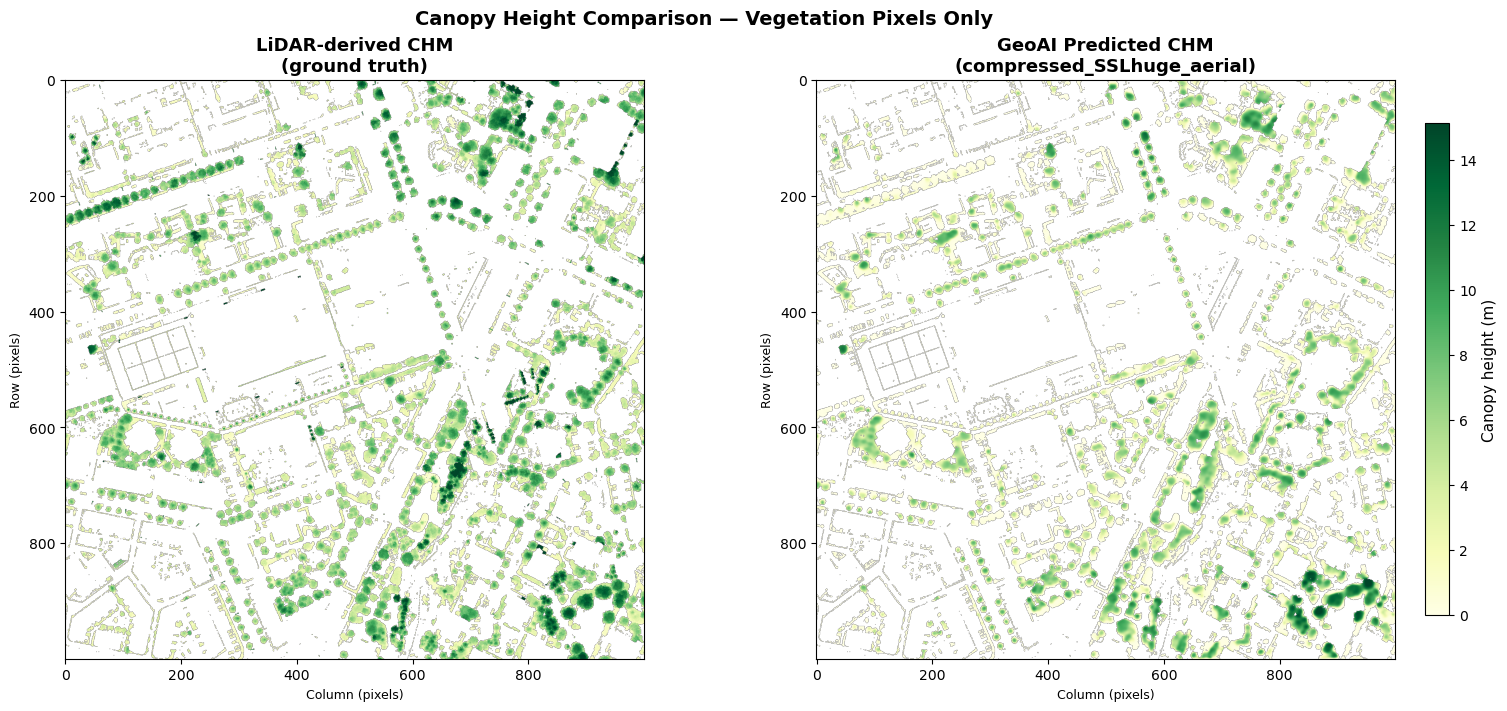

In [9]:
# ── Shared colour scale anchored to LiDAR distribution ───────────────────────
lidar_vals = lidar_masked[np.isfinite(lidar_masked)]
vmin = 0
vmax = np.percentile(lidar_vals, 99)   # exclude extreme outliers from colour scale

fig, axes = plt.subplots(1, 2, figsize=(16, 7), constrained_layout=True)

im1 = axes[0].imshow(lidar_masked, cmap="YlGn", vmin=vmin, vmax=vmax)
axes[0].set_title("LiDAR-derived CHM\n(ground truth)",
                  fontsize=13, fontweight="bold")

im2 = axes[1].imshow(geoai_masked, cmap="YlGn", vmin=vmin, vmax=vmax)
axes[1].set_title(f"GeoAI Predicted CHM\n({GEOAI_MODEL})",
                  fontsize=13, fontweight="bold")

for ax in axes:
    ax.axis("on")
    ax.ticklabel_format(style="plain")
    ax.xaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.yaxis.set_major_formatter(ScalarFormatter(useOffset=False))
    ax.set_xlabel("Column (pixels)", fontsize=9)
    ax.set_ylabel("Row (pixels)", fontsize=9)

cbar = fig.colorbar(im1, ax=axes, location="right",
                    shrink=0.85, pad=0.02)
cbar.set_label("Canopy height (m)", fontsize=11)

plt.suptitle("Canopy Height Comparison — Vegetation Pixels Only",
             fontsize=14, fontweight="bold")
plt.show()

---
## Step 5 — Statistical Validation

We quantify agreement between GeoAI and LiDAR using three complementary metrics:

| Metric | What it measures |
|--------|------------------|
| **R²** | Proportion of height variance explained — how well GeoAI tracks spatial patterns |
| **RMSE** | Root mean square error in metres — typical magnitude of per-pixel errors |
| **Mean bias** | Systematic over- or underestimation — is GeoAI consistently too high or too low? |

R² alone is insufficient: a model can have a high R² but still be systematically biased (always predicting, say, 60% of true height). RMSE and bias together reveal whether errors are random or structured.

In [10]:
# ── Extract valid pixel pairs for statistical comparison ──────────────────────
valid = np.isfinite(lidar_masked) & np.isfinite(geoai_masked)
y_true = lidar_masked[valid]   # LiDAR = ground truth
y_pred = geoai_masked[valid]   # GeoAI = prediction

print(f"Valid pixel pairs for comparison: {valid.sum():,}")

# ── Fit linear regression ─────────────────────────────────────────────────────
reg   = LinearRegression().fit(y_true.reshape(-1, 1), y_pred)
y_fit = reg.predict(y_true.reshape(-1, 1))

# ── Compute metrics ───────────────────────────────────────────────────────────
r2        = reg.score(y_true.reshape(-1, 1), y_pred)
rmse      = np.sqrt(mean_squared_error(y_true, y_pred))
mean_bias = np.mean(y_pred - y_true)   # positive = GeoAI overestimates
slope     = reg.coef_[0]
intercept = reg.intercept_

print("\nValidation metrics (vegetation pixels only):")
print(f"  R²         : {r2:.3f}")
print(f"  RMSE       : {rmse:.2f} m")
print(f"  Mean bias  : {mean_bias:+.2f} m  "
      f"({'underestimate' if mean_bias < 0 else 'overestimate'})")
print(f"  Regression : GeoAI = {slope:.2f} × LiDAR + {intercept:.2f}")

Valid pixel pairs for comparison: 238,797

Validation metrics (vegetation pixels only):
  R²         : 0.414
  RMSE       : 3.74 m
  Mean bias  : -2.47 m  (underestimate)
  Regression : GeoAI = 0.58 × LiDAR + -0.38


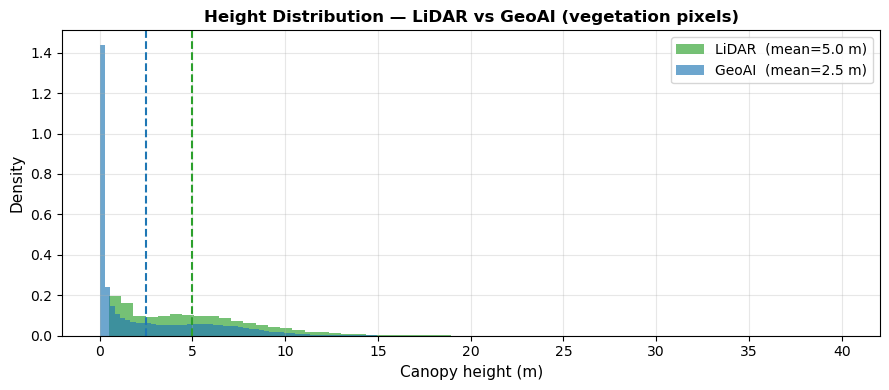

In [11]:
# ── Height distribution comparison ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

ax.hist(y_true, bins=60, alpha=0.65, color="#2ca02c",
        label=f"LiDAR  (mean={y_true.mean():.1f} m)", density=True)
ax.hist(y_pred, bins=60, alpha=0.65, color="#1f77b4",
        label=f"GeoAI  (mean={y_pred.mean():.1f} m)", density=True)

ax.axvline(y_true.mean(), color="#2ca02c", linestyle="--", linewidth=1.5)
ax.axvline(y_pred.mean(), color="#1f77b4", linestyle="--", linewidth=1.5)

ax.set_xlabel("Canopy height (m)", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Height Distribution — LiDAR vs GeoAI (vegetation pixels)",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

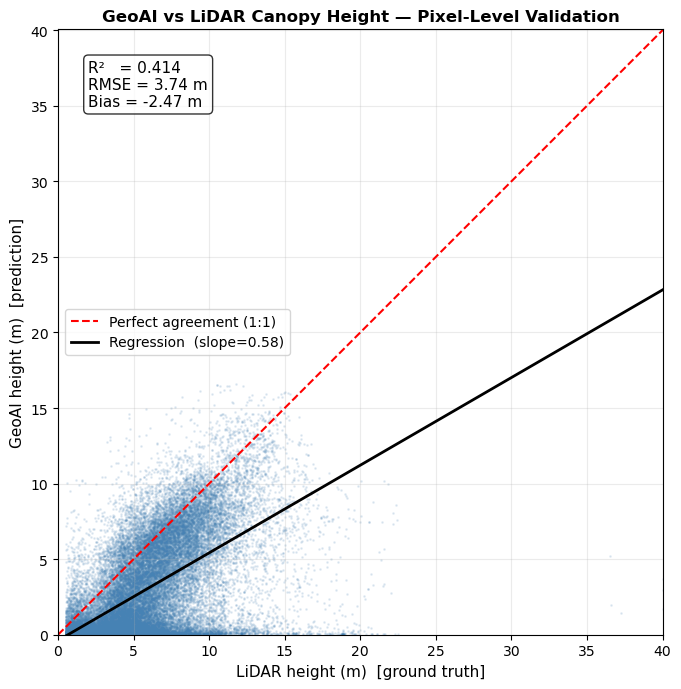

In [12]:
# ── Scatter plot: GeoAI vs LiDAR ─────────────────────────────────────────────
# Subsample for plotting speed (scatter with millions of points is slow)
n_plot = min(50_000, len(y_true))
idx    = np.random.choice(len(y_true), n_plot, replace=False)

fig, ax = plt.subplots(figsize=(7, 7))

ax.scatter(y_true[idx], y_pred[idx],
           s=1, alpha=0.12, color="steelblue", rasterized=True)

# 1:1 perfect agreement line
max_val = max(y_true.max(), y_pred.max())
ax.plot([0, max_val], [0, max_val], "r--",
        linewidth=1.5, label="Perfect agreement (1:1)")

# Fitted regression line
x_line = np.linspace(0, max_val, 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, "k-",
        linewidth=2, label=f"Regression  (slope={slope:.2f})")

# Annotate metrics
ax.text(0.05, 0.95,
        f"R²   = {r2:.3f}\nRMSE = {rmse:.2f} m\nBias = {mean_bias:+.2f} m",
        transform=ax.transAxes,
        fontsize=11, verticalalignment="top",
        bbox=dict(boxstyle="round", facecolor="white", alpha=0.8))

ax.set_xlabel("LiDAR height (m)  [ground truth]", fontsize=11)
ax.set_ylabel("GeoAI height (m)  [prediction]",   fontsize=11)
ax.set_title("GeoAI vs LiDAR Canopy Height — Pixel-Level Validation",
             fontsize=12, fontweight="bold")
ax.legend(fontsize=10)
ax.set_xlim(0, max_val)
ax.set_ylim(0, max_val)
ax.set_aspect("equal")
ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

---
## Step 6 — Spatial Residual Map

Aggregate accuracy metrics (R², RMSE) tell you *how much* error there is on average, but not *where* it occurs. The residual map answers the spatial question:

- **Red pixels** → GeoAI underestimates (predicts lower than LiDAR) — typically tall closed-canopy trees where the model cannot "see" through
- **Blue pixels** → GeoAI overestimates — typically at canopy edges, isolated trees, or areas where aerial texture is ambiguous
- **White pixels** → Good agreement

This map is the most actionable output for a practitioner: it shows exactly which areas of a city can rely on GeoAI for canopy height, and which require LiDAR.

Residual statistics:
  Mean bias  : -2.47 m
  Std dev    : 2.81 m
  P5  / P95  : -7.5 m / +1.1 m
  Colour scale: ±8.9 m


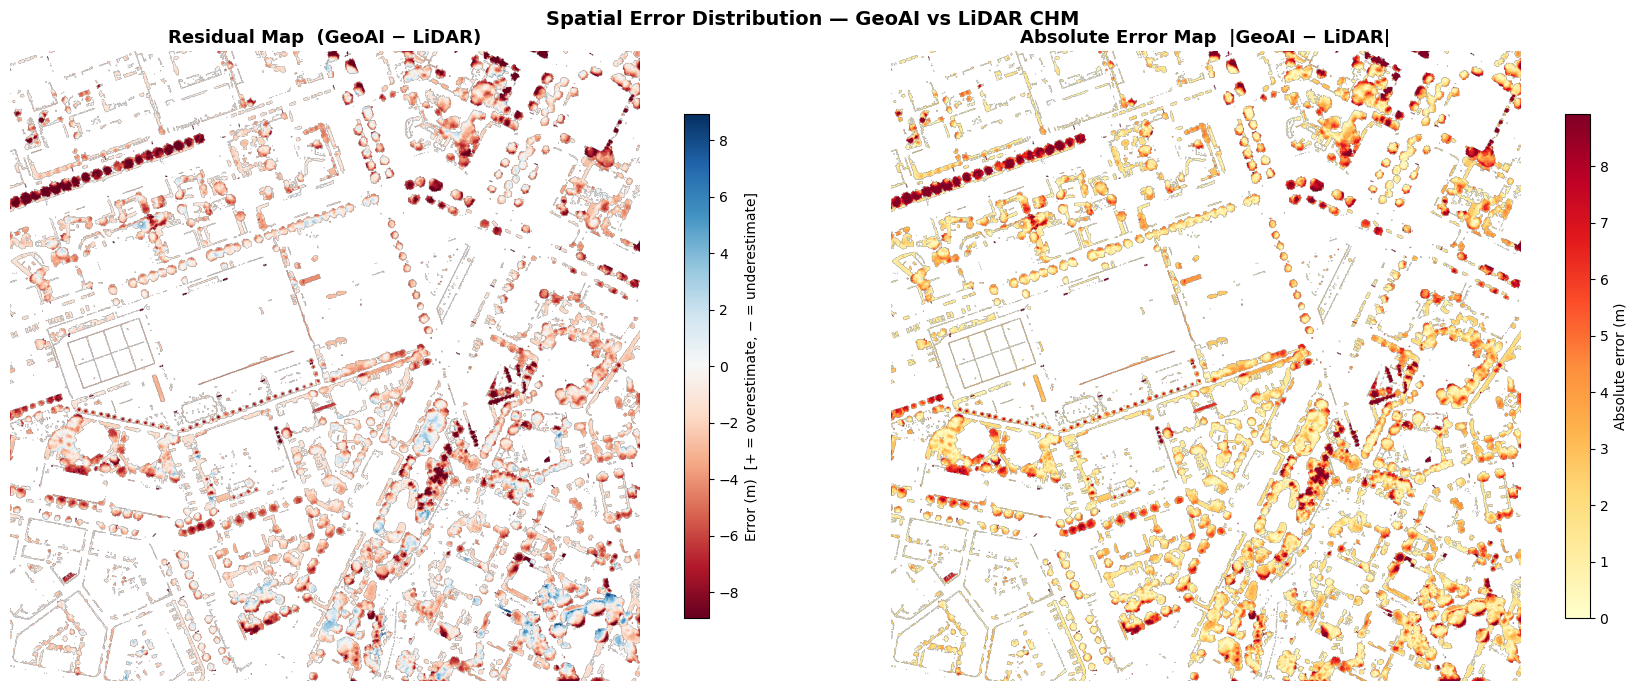

In [13]:
# ── Compute residual: GeoAI − LiDAR ──────────────────────────────────────────
# Positive = GeoAI overestimates; Negative = GeoAI underestimates
residual = geoai_masked - lidar_masked   # NaN outside vegetation mask

# Symmetric colour scale centred on zero
res_vals  = residual[np.isfinite(residual)]
clim      = np.percentile(np.abs(res_vals), 97)   # clip extreme outliers

print(f"Residual statistics:")
print(f"  Mean bias  : {res_vals.mean():+.2f} m")
print(f"  Std dev    : {res_vals.std():.2f} m")
print(f"  P5  / P95  : {np.percentile(res_vals, 5):+.1f} m / {np.percentile(res_vals, 95):+.1f} m")
print(f"  Colour scale: ±{clim:.1f} m")

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# ── Left: residual map ────────────────────────────────────────────────────────
im_res = axes[0].imshow(
    residual,
    cmap="RdBu",        # red = underestimate, blue = overestimate
    vmin=-clim, vmax=clim
)
axes[0].set_title("Residual Map  (GeoAI − LiDAR)",
                  fontsize=13, fontweight="bold")
axes[0].axis("off")
cbar_res = plt.colorbar(im_res, ax=axes[0], shrink=0.8)
cbar_res.set_label("Error (m)  [+ = overestimate, − = underestimate]",
                   fontsize=10)

# ── Right: absolute error map ─────────────────────────────────────────────────
abs_error = np.abs(residual)
im_abs = axes[1].imshow(
    abs_error,
    cmap="YlOrRd",
    vmin=0, vmax=clim
)
axes[1].set_title("Absolute Error Map  |GeoAI − LiDAR|",
                  fontsize=13, fontweight="bold")
axes[1].axis("off")
cbar_abs = plt.colorbar(im_abs, ax=axes[1], shrink=0.8)
cbar_abs.set_label("Absolute error (m)", fontsize=10)

plt.suptitle("Spatial Error Distribution — GeoAI vs LiDAR CHM",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

---
## Summary and Interpretation

| Metric | Value |
|--------|-------|
| **R²** | Computed and printed by the Step 5 stats cell |
| **RMSE** | Computed and printed by the Step 5 stats cell |
| **Mean bias** | Computed and printed — negative = systematic underestimate |
| **Pixels compared** | Vegetation only (LiDAR CHM > 0.01 m) |
| **Reference** | LiDAR 0.5 m CHM (Notebook 02) |
| **Prediction** | GeoAI `compressed_SSLhuge_aerial` from 5 cm orthophoto |

### Key findings

**What GeoAI does well:**
- Captures the **spatial pattern** of canopy height — tall trees are predicted taller than short ones (positive R²)
- Performs well for **low to mid canopy** (roughly 2–15 m), where aerial texture provides sufficient signal
- Requires only RGB imagery — no specialist equipment or processing

**Where GeoAI falls short:**
- **Systematically underestimates tall canopy** (>15 m) — the model cannot resolve the true top of dense closed-canopy trees from aerial perspective alone
- **Canopy edge overestimation** — isolated trees and crown edges often receive inflated predictions due to texture contrast with surrounding surfaces

### Practical guidance — when to use which method

| Use case | Recommended method |
|----------|--------------------|
| Vegetation *structure* classification (low / mid / high) | ✅ GeoAI sufficient for vegetation layers; provided an independent vegetation mask (e.g. NDVI from multispectral imagery) |
| Individual tree *height* for carbon stock estimation | ⚠️ LiDAR required — GeoAI underestimates tall trees |
| Precise crown delineation | ⚠️ LiDAR required |

### What this pipeline delivers for clients
- **Cost-benefit evidence** — quantified accuracy trade-off between expensive LiDAR and free aerial imagery enables informed procurement decisions
- **Spatial uncertainty map** — the residual raster identifies exactly which areas of a study site require LiDAR-quality data, rather than assuming uniform accuracy
- **Method transferability** — the same validation pipeline can be applied to any city with open LiDAR and aerial imagery to benchmark GeoAI performance locally before operational deployment